# Caso de Estudio 2: Aprendizaje No Supervisado Completo
Este notebook cubre todos los algoritmos de **Aprendizaje No Supervisado**:
1. **PCA** (Análisis de Componentes Principales).
2. **K-Means Clustering** (Optimizado con Codo e Inercia).
3. **Clustering Jerárquico** (Ward, Complete, Dendrogramas y Cofenético).
4. **SOM** (Self-Organizing Maps) con asignación de etiquetas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

# Para SOM (MiniSom)
from minisom import MiniSom

import warnings
warnings.filterwarnings('ignore')


## 1. Preprocesamiento y PCA


In [2]:
# Carga de datos
df = pd.read_csv('Sem_12/clientes_tienda.csv')
X = df[['Age', 'Annual Income ($)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducción PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Varianza explicada acumulada PCA:", sum(pca.explained_variance_ratio_)*100, "%")


Varianza explicada acumulada PCA: 68.6260604144785 %


## 2. K-Means y su Optimización


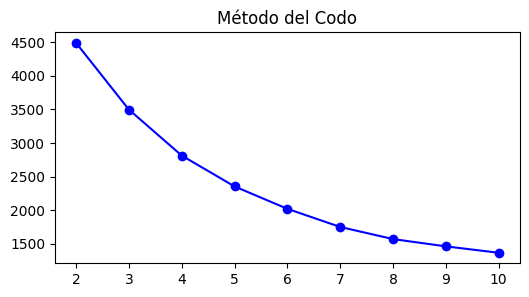

In [3]:
# Codo e Inercia
wcss = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(k_range, wcss, 'bo-')
plt.title('Método del Codo')
plt.show()


## 3. Clustering Jerárquico


Cofenética Ward: 0.5132 | Cofenética Complete: 0.5045


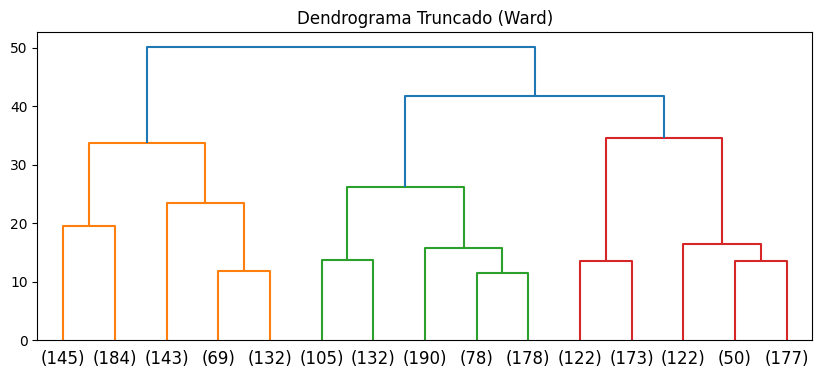

In [4]:
Z_ward = linkage(df_scaled if 'df_scaled' in locals() else X_scaled, method='ward')
Z_complete = linkage(df_scaled if 'df_scaled' in locals() else X_scaled, method='complete')

# Correlación cofenética
c_ward, _ = cophenet(Z_ward, pdist(X_scaled))
c_comp, _ = cophenet(Z_complete, pdist(X_scaled))
print(f"Cofenética Ward: {c_ward:.4f} | Cofenética Complete: {c_comp:.4f}")

plt.figure(figsize=(10, 4))
dendrogram(Z_ward, truncate_mode='lastp', p=15)
plt.title('Dendrograma Truncado (Ward)')
plt.show()


## 4. Mapas Auto-Organizados (SOM)


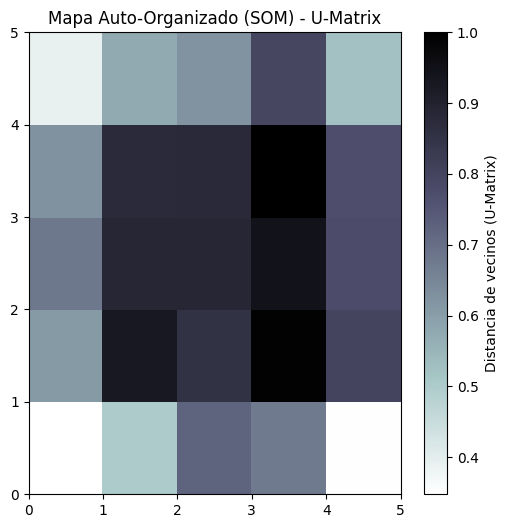

In [5]:
# Inicialización y entrenamiento de un SOM simple de 5x5
som_shape = (5, 5)
som = MiniSom(som_shape[0], som_shape[1], X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train_random(X_scaled, 500)

# U-Matrix para visualizar distancias entre neuronas
plt.figure(figsize=(6, 6))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distancia de vecinos (U-Matrix)')
plt.title('Mapa Auto-Organizado (SOM) - U-Matrix')
plt.show()


## 5. Banco de Preguntas Teóricas (Nivel Examen)
*   **Pregunta 1:** ¿Por qué SOM preserva la topología de los datos a diferencia de PCA?
    *   *Respuesta:* PCA proyecta de forma lineal buscando ejes de varianza máxima, distorsionando distancias globales complejas no lineales. SOM mapea de forma no lineal los datos sobre una cuadrícula regular 2D, donde datos vecinos en el espacio de alta dimensión quedan mapeados en neuronas vecinas de la cuadrícula.
*   **Pregunta 2:** ¿Qué implicancias tiene un Coeficiente Cofenético bajo en un enlace jerárquico?
    *   *Respuesta:* Significa que el dendrograma generado no es una representación fiel de las distancias originales de los datos, por lo que las fusiones en el árbol no son muy confiables.
